In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("adult.csv")
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [12]:
df.duplicated().sum()

52

In [13]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [14]:
df.shape

(48842, 15)

In [7]:
df.describe()

,39,77516,13,2174,0,40
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [18]:
df.isin(['?']).sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [19]:
df['workclass'] = df['workclass'].replace('?',np.nan)
df['occupation'] = df['occupation'].replace('?',np.nan)
df['native-country'] = df['native-country'].replace('?',np.nan)

In [23]:
info = pd.DataFrame(df.isnull().sum(),columns=['IsNull'])
info.insert(1,'IsNa',df.isna().sum(),True)
info.insert(2,'Deplicate',df.duplicated().sum(),True)
info.insert(3,'Unique',df.nunique().sum(),True)
info

,IsNull,IsNa,Deplicate,Unique
age,0,0,52,29032
workclass,2799,2799,52,29032
fnlwgt,0,0,52,29032
education,0,0,52,29032
educational-num,0,0,52,29032
marital-status,0,0,52,29032
occupation,2809,2809,52,29032
relationship,0,0,52,29032
race,0,0,52,29032
gender,0,0,52,29032


In [24]:
df['education'].unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [26]:
df['educational-num'].unique()

array([ 7,  9, 12, 10,  6, 15,  4, 13, 14, 16,  3, 11,  5,  8,  2,  1])

Text(0.5, 1.0, 'Histogram')

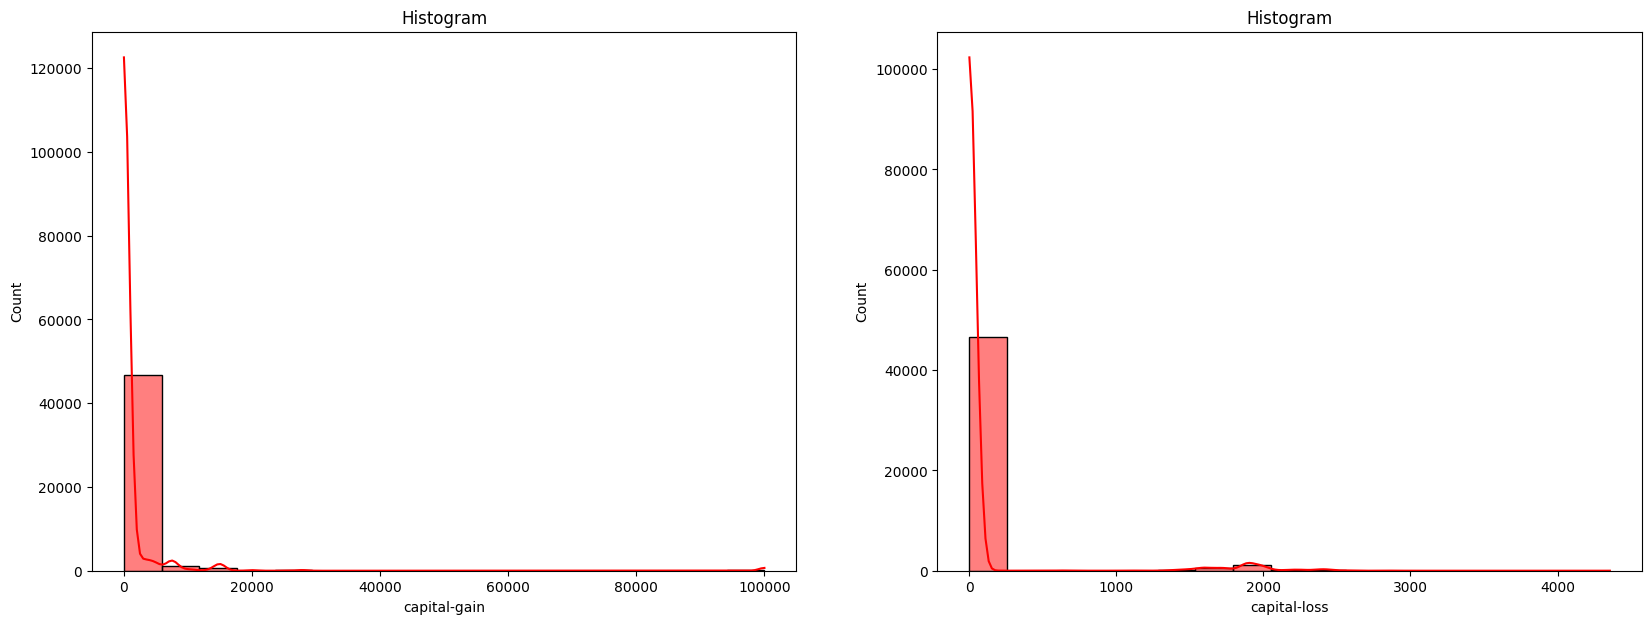

In [27]:
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
sns.histplot(df['capital-gain'],kde=True,color='r')
plt.title("Histogram")
plt.subplot(1,2,2)
sns.histplot(df['capital-loss'],kde=True,color='r')
plt.title("Histogram")

In [35]:
df.drop(['capital-gain','capital-loss','educational-num'],axis=1,inplace=True)

In [36]:
from sklearn import preprocessing

label_endcoder = preprocessing.LabelEncoder()

df['gender'] = label_endcoder.fit_transform(df['gender'])
df['workclass'] = label_endcoder.fit_transform(df['workclass'])
df['education'] = label_endcoder.fit_transform(df['education'])
df['marital-status'] = label_endcoder.fit_transform(df['marital-status'])
df['occupation'] = label_endcoder.fit_transform(df['occupation'])
df['relationship'] = label_endcoder.fit_transform(df['relationship'])
df['race'] = label_endcoder.fit_transform(df['race'])
df['native-country'] = label_endcoder.fit_transform(df['native-country'])
df['income'] = label_endcoder.fit_transform(df['income'])

In [38]:
df.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
0,25,3,226802,1,4,6,3,2,1,40,38,0
1,38,3,89814,11,2,4,0,4,1,50,38,0
2,28,1,336951,7,2,10,0,4,1,40,38,1
3,44,3,160323,15,2,6,0,2,1,40,38,1
4,18,8,103497,15,4,14,3,4,0,30,38,0


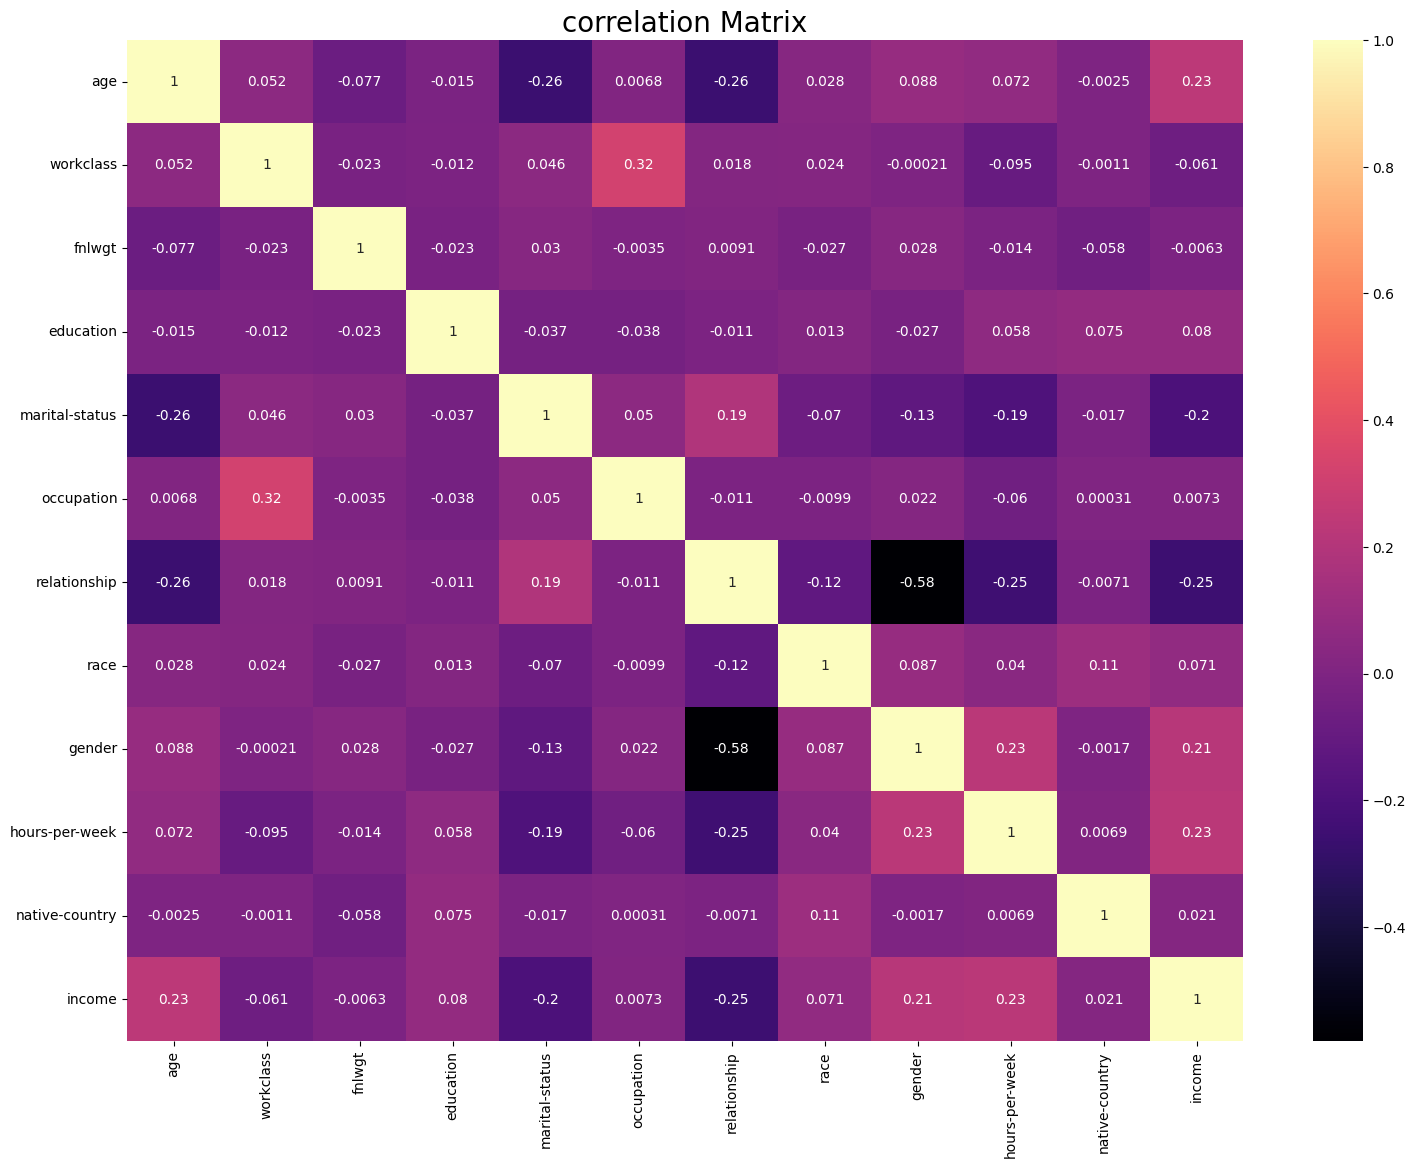

In [39]:
f, ax = plt.subplots(figsize=[18,13])
sns.heatmap(df.corr(),annot=True, ax=ax,cmap='magma')
ax.set_title('correlation Matrix',fontsize=20)
plt.show()

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import metrics

In [51]:
x = df.drop(columns={'income'},axis=1)
y = df['income'].values.ravel()

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)
print('x_train_shape',x_train.shape)
print('y_train_shape',y_train.shape)
print('x_test_shape',x_train.shape)
print('y_test_shape',y_train.shape)

x_train_shape (39073, 11)
y_train_shape (39073,)
x_test_shape (39073, 11)
y_test_shape (39073,)


In [53]:
#Find best K
k = 20
error = []
acc = []
for i in range(1,k+1):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    error.append(1-metrics.accuracy_score(y_test,y_pred))
    acc.append(metrics.accuracy_score(y_test,y_pred))

Text(0.5, 1.0, 'accuracy')

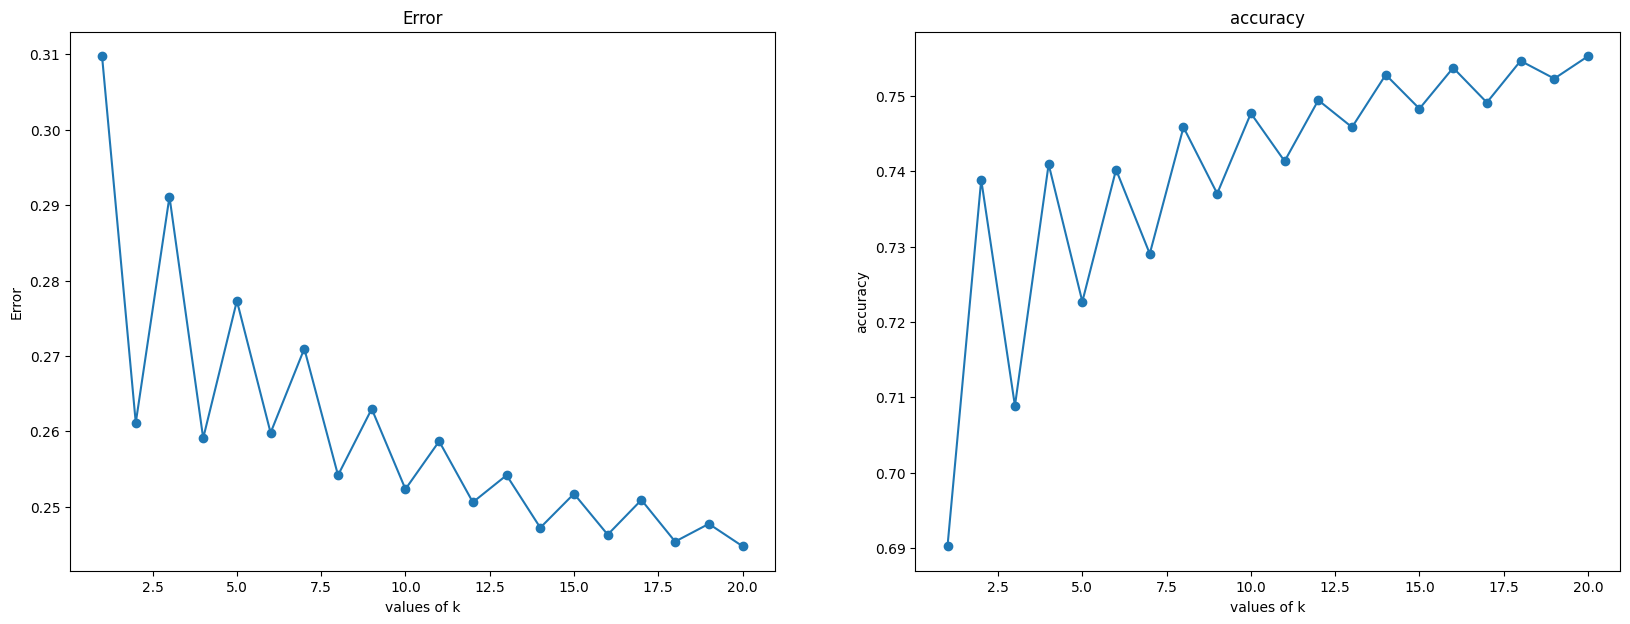

In [60]:
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
plt.plot(range(1,21),error,marker='o')
plt.xlabel('values of k')
plt.ylabel('Error')
plt.title('Error')

plt.subplot(1,2,2)
plt.plot(range(1,21),acc,marker='o')
plt.xlabel('values of k')
plt.ylabel('accuracy')
plt.title('accuracy')

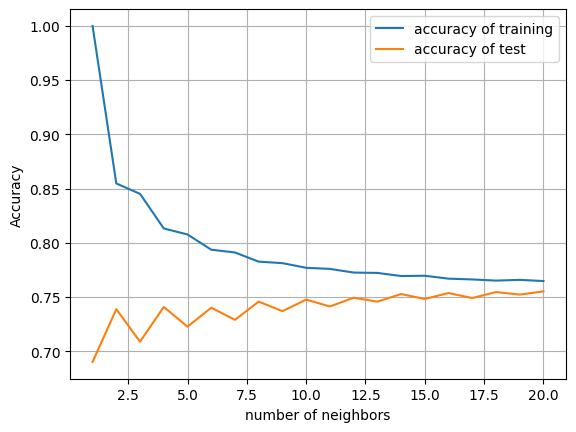

In [64]:
train_acc = []
test_acc = []

neigh_set = range(1,21)
for n_neighbord in neigh_set:
    knn = KNeighborsClassifier(n_neighbors=n_neighbord,)
    knn.fit(x_train,y_train.ravel())
    train_acc.append(knn.score(x_train,y_train))
    test_acc.append(knn.score(x_test,y_test))

plt.plot(neigh_set,train_acc,label='accuracy of training')
plt.plot(neigh_set,test_acc,label='accuracy of test')
plt.ylabel('Accuracy')
plt.xlabel('number of neighbors')
plt.grid()
plt.legend()
plt.show()





In [67]:
pars = {'n_neighbors': range(1, 30)}

grid_kn = GridSearchCV(
    estimator=knn,
    param_grid=pars,
    scoring='accuracy',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_kn.fit(x_train, y_train.ravel())

Fitting 10 folds for each of 29 candidates, totalling 290 fits


,estimator,KNeighborsCla..._neighbors=20)
,param_grid,"{'n_neighbors': range(1, 30)}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,28


In [68]:
grid_kn.best_params_

{'n_neighbors': 28}

In [70]:
knn_best = KNeighborsClassifier(n_neighbors=28)
knn_best.fit(x_train,y_train.ravel())
y_pred_best = knn_best.predict(x_test)
metrics.accuracy_score(y_test,y_pred_best)

0.7562698331456649